## Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd




## Data understanding

#### Unzipping the files

In [3]:
##Unzipping

def unzip_and_list(zip_path, extract_to):
    """
    Unzips the given zip file and returns all files and folders inside it.

    :param zip_path: Path to the zip file
    :param extract_to: Folder where files should be extracted
    :return: List of file and folder paths inside the extracted directory
    """

    # --- Unzip the file ---
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    # --- Walk through extracted directory ---
    all_items = []
    for root, dirs, files in os.walk(extract_to):
        for d in dirs:
            all_items.append(os.path.join(root, d))
        for f in files:
            all_items.append(os.path.join(root, f))

    return all_items


In [4]:
zip_file_path = "/content/walmart-recruiting-store-sales-forecasting.zip"
extract_folder = "/content/extracted"

items = unzip_and_list(zip_file_path, extract_folder)

for item in items:
    print(item)


/content/extracted/sampleSubmission.csv.zip
/content/extracted/train.csv.zip
/content/extracted/features.csv.zip
/content/extracted/test.csv.zip
/content/extracted/stores.csv


#### Datasets

###### 1.  Store dataset

In [5]:
store_df=pd.read_csv("/content/extracted/stores.csv")

In [6]:
store_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [7]:
#checking unique values

###### 2.  features dataset

In [8]:
unzip_and_list('/content/extracted/features.csv.zip', '/content/extracted')


['/content/extracted/sampleSubmission.csv.zip',
 '/content/extracted/train.csv.zip',
 '/content/extracted/features.csv.zip',
 '/content/extracted/test.csv.zip',
 '/content/extracted/features.csv',
 '/content/extracted/stores.csv']

In [9]:
feature_df=pd.read_csv('/content/extracted/features.csv')

###### 2.  train dataset

In [10]:
unzip_and_list('/content/extracted/train.csv.zip', '/content/extracted')


['/content/extracted/sampleSubmission.csv.zip',
 '/content/extracted/train.csv.zip',
 '/content/extracted/features.csv.zip',
 '/content/extracted/train.csv',
 '/content/extracted/test.csv.zip',
 '/content/extracted/features.csv',
 '/content/extracted/stores.csv']

In [11]:
train_df=pd.read_csv('/content/extracted/train.csv')

### Merging these datasets

#### Understanding store's Dataset

In [12]:
store_df.columns

Index(['Store', 'Type', 'Size'], dtype='object')

In [13]:
store_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [14]:
#unique values in each columns

for col in store_df.columns:
  print(col)
  print(store_df[col].unique())

Store
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Type
['A' 'B' 'C']
Size
[151315 202307  37392 205863  34875 202505  70713 155078 125833 126512
 207499 112238 219622 200898 123737  57197  93188 120653 203819 203742
 140167 119557 114533 128107 152513 204184 206302  93638  42988 203750
 203007  39690 158114 103681  39910 184109 155083 196321  41062 118221]


In [15]:
store_df.shape

(45, 3)

**Store Dataset**

* The Store dataset contains basic information about Walmart stores.
* It includes 45 rows, meaning data for 45 different stores, and 3 columns in total.

**Columns Explanation**

* Store  
  - This column represents the unique ID of each store.  
  - The values range from 1 to 45, where each number refers to a different physical Walmart store.

* Type  
  - This column shows the type of store.  
  - There are three types: A, B, and C.  
    * Type A stores are large in size and usually generate high sales.  
    * Type B stores are medium-sized stores.  
    * Type C stores are smaller stores with comparatively lower sales.

* Size  
  - This column represents the physical size of the store, usually measured in square feet.  
  - Store size helps in understanding the selling capacity of the store.

**Why this dataset matters**

* This dataset provides static information about each store.
* It helps the model understand how different store types and sizes affect sales.
* Using this information improves the accuracy of sales prediction and forecasting.


-----------------------------------------------------------

#### Understanding Feature dataset

In [16]:
feature_df.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')

In [17]:
feature_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [18]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [19]:
feature_df.shape

(8190, 12)

**Features Dataset**

* The Features dataset contains 8190 rows and 12 columns additional information that affects sales on a weekly basis.
* This dataset changes over time and is linked to each store and each week.
* It helps the model understand external and economic factors that influence sales.

**Columns Explanation**

* Store  
  - Represents the unique store ID (from 1 to 45).  
  - Used to connect this dataset with the Store and Sales datasets.

* Date  
  - Represents the specific week for which the data is recorded. Usually, this date is the week-end date, and it captures the average sales for the week, average temperature, CPI, unemployment rate, etc.
  - It represents the entire week as a unit
  - This allows the model to learn weekly and seasonal sales patterns.


* Temperature  
  - Shows the average temperature for that week in the store’s region.  
  - Weather can influence customer behaviour and sales.

* Fuel_Price  
  - Represents the fuel price during that particular week.  
  - Higher fuel prices can reduce customer visits and impact sales.

* Markdown 1-5
  - Amount of propotional discounts for that week

* CPI (Consumer Price Index)  
  - Indicates the level of inflation during that week.  
  - Inflation affects purchasing power and overall consumer spending.

* Unemployment  
  - Represents the Avg unemployment rate for that week.  
  - Higher unemployment generally leads to lower consumer spending.

* IsHoliday  
  - A boolean feature (True/False).  
  - Indicates whether the given week contains a major holiday.  
  - Holiday weeks usually have higher sales compared to normal weeks.

**Why this dataset matters**

* The Features dataset provides important external and economic context.
* It helps the model understand why sales change even when store details remain the same.
* Including these features improves the model’s ability to capture seasonality and real-world effects on sales.
* Promotions directly influence customer buying behaviour.




#### Understanding train's Dataset

In [20]:
train_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

In [21]:
train_df.shape

(421570, 5)

In [22]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


#### Merging

I merge the Stores data with the features data using **Store**, **Date**, and **IsHoliday** because sales change from week to week, and these columns make sure that each sales record is matched with the correct store, the correct week, and the correct holiday status; using only the store would mix up features from different weeks and give wrong information to the model.
After that, we merge with the store dataset using only Store because store details like type and size never change over time, so the same information applies to all weeks of that store.

In [23]:
merge=pd.merge(train_df,feature_df,on=['Store','Date','IsHoliday'])

In [24]:
merge_df=pd.merge(merge,store_df,on=['Store'])

In [25]:
merge_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [26]:
#saving for future purpose
merge_df.to_csv("original.csv", index=False)


### Data preprocessing

In [27]:
#size
merge_df.shape

(421570, 16)

In [28]:
#columns in final dataset after merging
merge_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [29]:
#checking null values
merge_df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


Markdown columns have some null values

In [30]:
#checking for outliers
merge_df.MarkDown1.describe()

,MarkDown1
count,150681.000000
mean,7246.420196
std,8291.221345
min,0.270000
25%,2240.270000
50%,5347.450000
75%,9210.900000
max,88646.760000


There is a drastic difference between the 75% and maximum values in the MarkDown columns, indicating the presence of outliers; however, these outliers should be kept because they represent genuine promotional or holiday discount events and removing them would eliminate important business signals needed for accurate sales forecasting.

In [31]:
#Filling these null values with zero
merge_df.MarkDown1.fillna(0,inplace=True)
merge_df.MarkDown2.fillna(0,inplace=True)
merge_df.MarkDown3.fillna(0,inplace=True)
merge_df.MarkDown4.fillna(0,inplace=True)
merge_df.MarkDown5.fillna(0,inplace=True)

In [32]:
#checking
merge_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [33]:
#checking for duplicate
merge_df.duplicated().sum()

np.int64(0)

In [34]:
#checking outlier
merge_df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


Observations

* **Negative Sales Values**  
  Some sales values in the dataset are negative, which may seem surprising at first. However, this can occur in real-world retail scenarios due to returns or refunds. If the value of returned items exceeds the value of sales in a given week, the net weekly sales can become negative. Therefore, these negative values are realistic and reflect actual business situations rather than data errors.

* **Unemployment Rate**  
  The unemployment column represents the unemployment rate, most likely expressed as a percentage. Since this dataset is based on Walmart stores located in the United States, the unemployment values correspond to U.S. unemployment statistics for the given time period and region. This feature helps capture the overall economic condition affecting consumer spending.

* **CPI (Consumer Price Index)**  
  CPI stands for Consumer Price Index, which measures the average change over time in prices paid by consumers for goods and services. It is a commonly used indicator of inflation. Higher CPI values generally indicate rising prices, which can impact purchasing power and, in turn, sales behavior.

* **Dept Column**  
  The Dept column represents different departments within a Walmart store, not monetary debt. Each number is simply an identifier for a specific department, such as groceries, electronics, or clothing. That is why the values appear as numbers (for example, 19); they are categorical identifiers rather than numerical quantities.


## EDA

### **Distribution**

In [35]:

def plot_distributions(df, columns):

    plt.style.use('seaborn-v0_8')

    numeric_cols = [col for col in columns if pd.api.types.is_numeric_dtype(df[col])]

    if not numeric_cols:
        print("No valid numerical columns found.")
        return

    rows = len(numeric_cols)
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))

    if rows == 1:
        axes = np.array([axes])

    fig.suptitle("Distribution Plots for Selected Numerical Columns",
                 fontsize=22, fontweight="bold", y=1.02)

    for i, col in enumerate(numeric_cols):
        data = df[col].dropna()

        axes[i, 0].boxplot(data, patch_artist=True,
                           boxprops=dict(facecolor="#87CEFA", color="black"),
                           medianprops=dict(color="red", linewidth=2))
        axes[i, 0].set_title(f"Boxplot of {col}")
        axes[i, 0].grid(True, linestyle="--", alpha=0.4)

        axes[i, 1].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[i, 1].set_title(f"Histogram of {col}")
        axes[i, 1].grid(True, linestyle="--", alpha=0.4)


        kde_line = data.plot(kind="density", ax=axes[i, 2], linewidth=2)
        line = kde_line.lines[0]

        x_vals = line.get_xdata()
        y_vals = line.get_ydata()

        axes[i, 2].fill_between(x_vals, y_vals, alpha=0.15)
        axes[i, 2].set_title(f"KDE of {col}")
        axes[i, 2].grid(True, linestyle="--", alpha=0.4)

        for j in range(3):
            axes[i, j].set_xlabel(col, fontsize=12)

    plt.tight_layout(pad=2, w_pad=3, h_pad=3)
    plt.show()


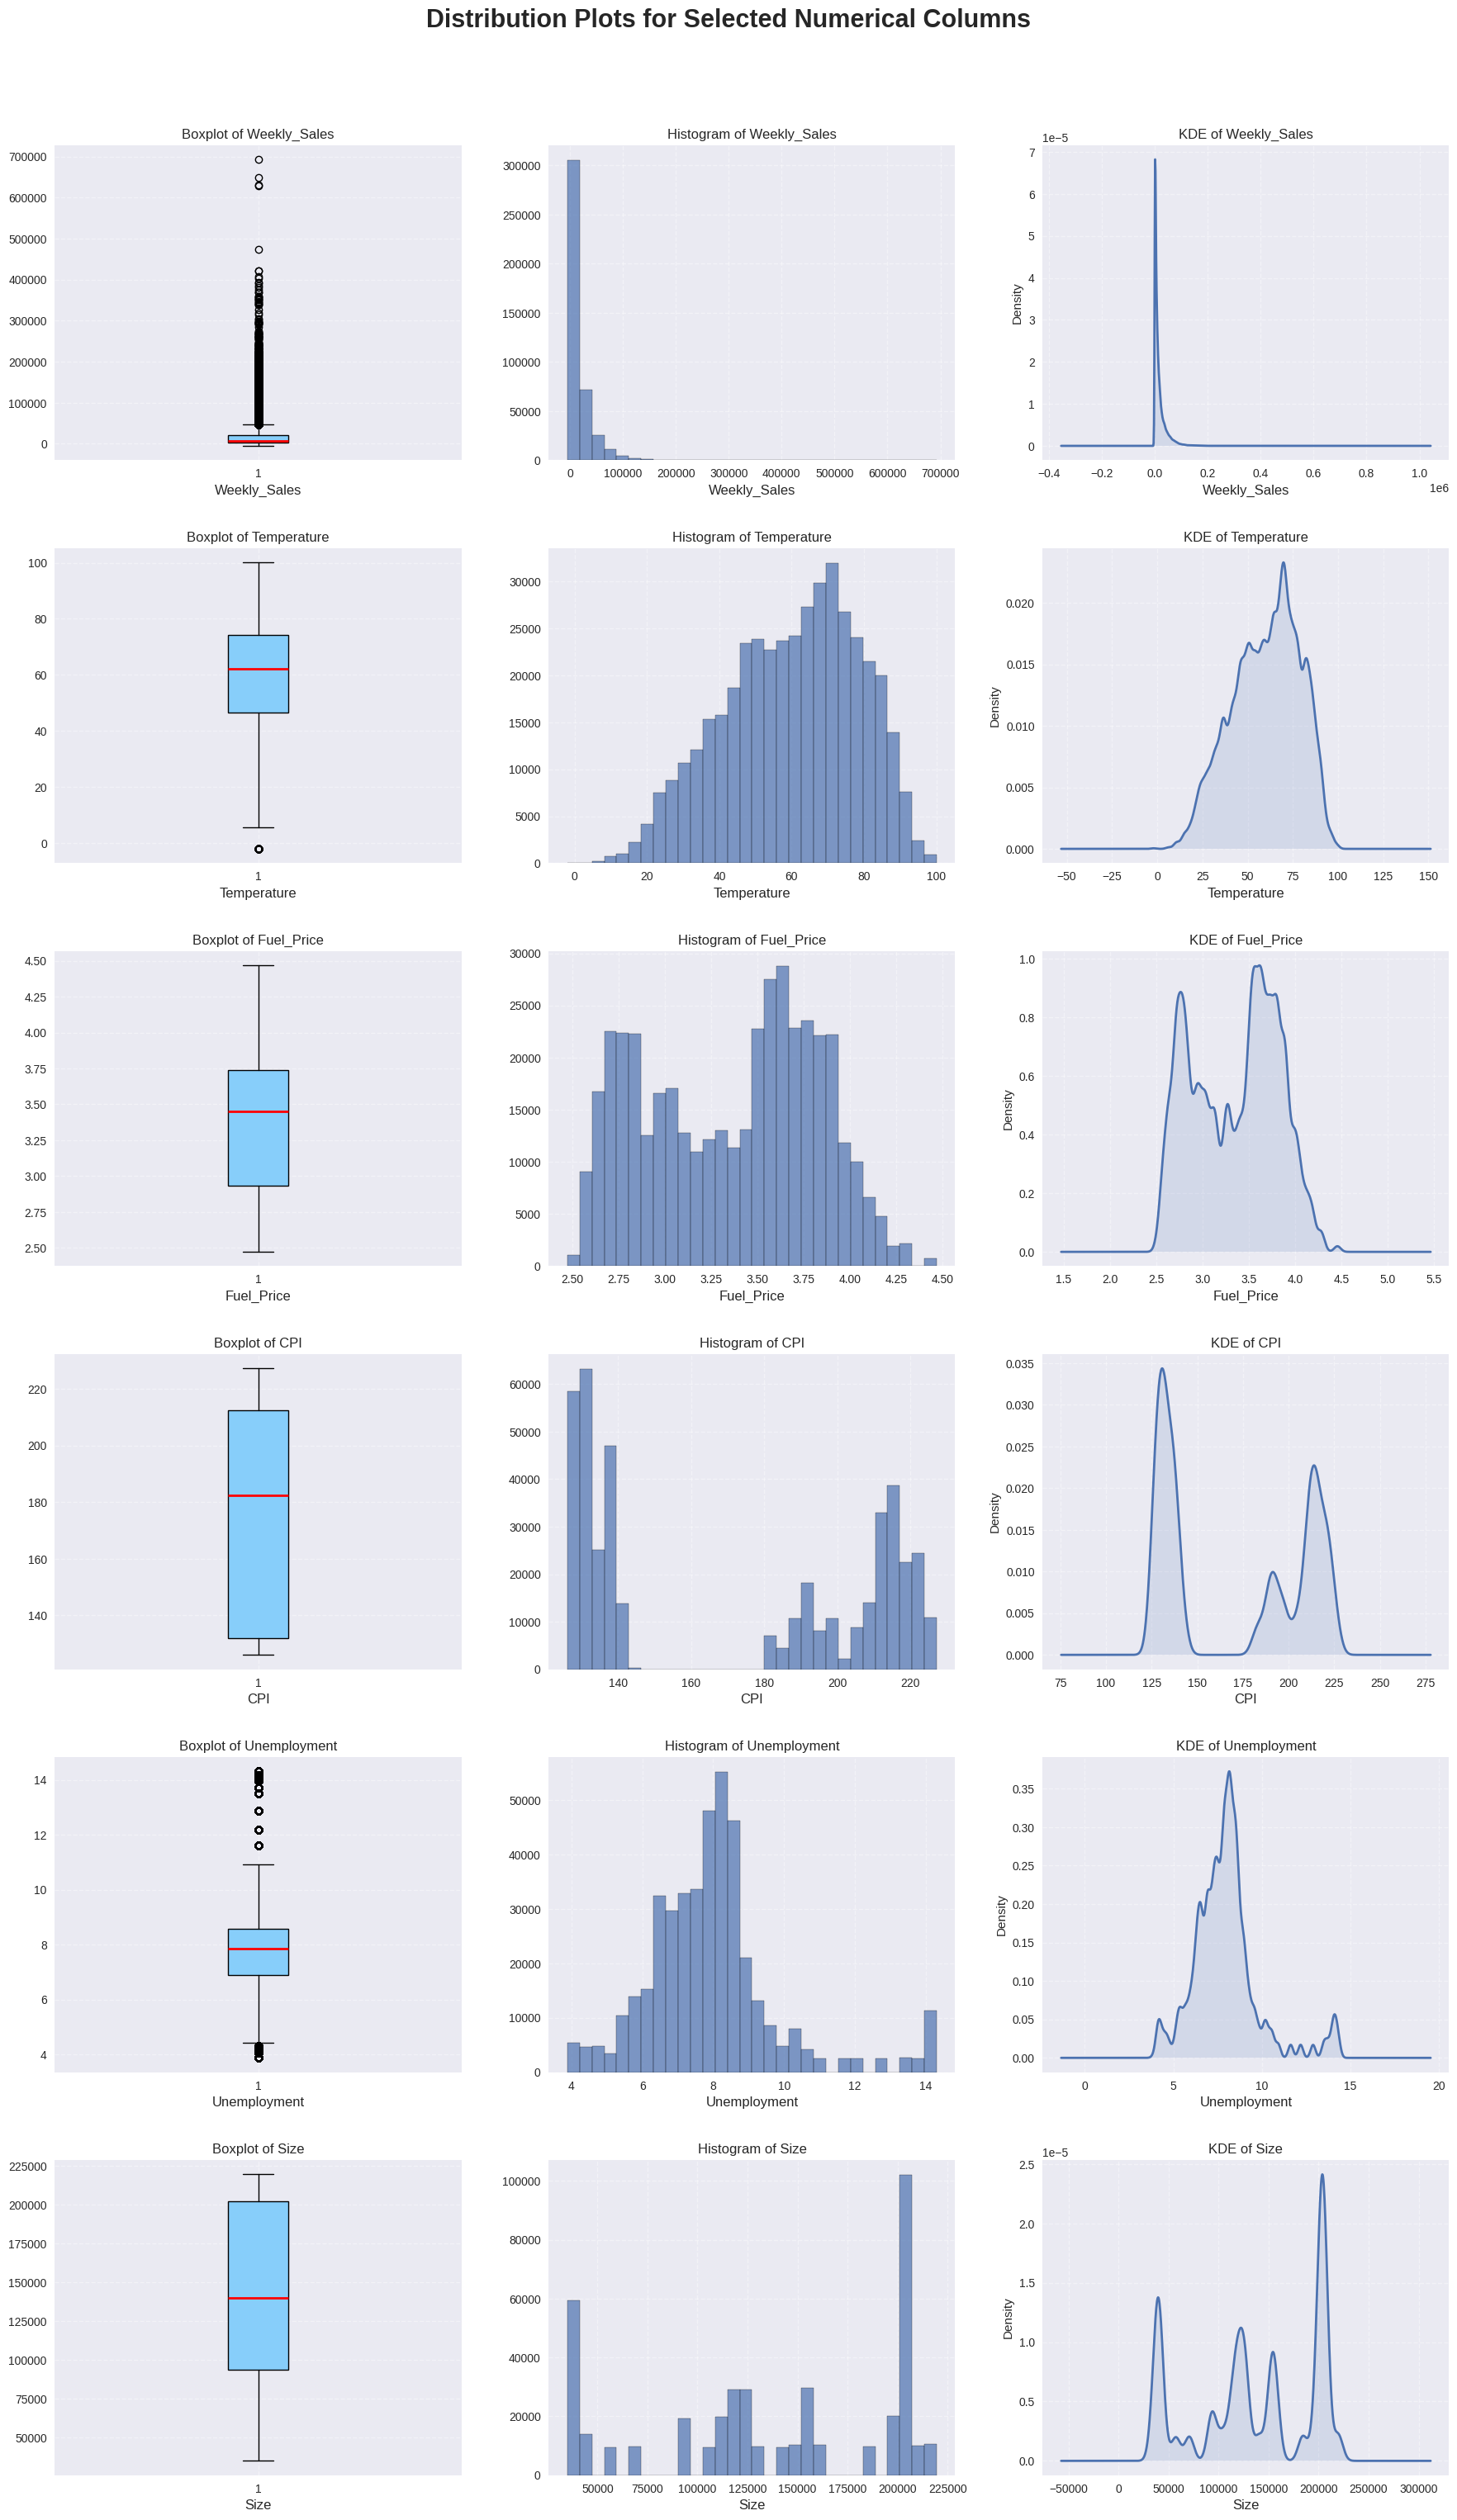

In [36]:
cols_to_plot = ["Weekly_Sales", "Temperature", "Fuel_Price",'CPI','Unemployment','Size']

plot_distributions(merge_df, cols_to_plot)


#### 1. Weekly Sales (Target Variable)

* **Observations**
  * Extremely right-skewed distribution: most weekly sales values are low, while a few are very high.
  * Presence of extreme outliers, with some store–department combinations reaching up to ~$700K per week.
  * KDE peaks near zero, indicating that most rows have small to medium weekly sales.

* **Interpretation**
  * This behaviour is completely normal in retail data.
  * Some departments (e.g., groceries) sell consistently, while others sell infrequently.
  * Outliers represent real business events such as holidays, promotions, and Black Friday weeks.


#### 2. Temperature

* **Observations**
  * Temperature ranges from near freezing (~5°F) to around 100°F.
  * The distribution is bell-shaped, matching typical US climate patterns.

* **Interpretation**
  * The dataset includes Walmart stores across different regions of the USA.
  * Northern states experience colder temperatures, while southern states are warmer.
  * Temperature impacts:
    * Demand for seasonal products (ice creams, heaters, jackets)
    * Customer footfall (bad weather can reduce store visits)



#### 3. Fuel Price

* **Observations**
  * Values cluster around ~2.6, ~3.0, and ~3.3, forming multiple peaks.
  * These patterns align with real US fuel price cycles during 2010–2012.

* **Interpretation**
  * Higher fuel prices can reduce travel frequency, leading to fewer store visits.
  * This is a strong macroeconomic indicator affecting consumer behaviour.


#### 4. CPI (Consumer Price Index)

* **Observations**
  * The distribution is multi-modal with several peaks.
  * CPI values range approximately from 130 to 220.

* **Interpretation**
  * CPI varies across regions in the USA.
  * Stores located in metro or expensive areas show higher CPI values.
  * Higher CPI indicates higher living costs, which can influence purchasing behaviour.



#### 5. Unemployment

* **Observations**
  * Most values lie between 7% and 10%.
  * Some spikes are observed near 14%.

* **Interpretation**
  * The dataset spans a period (2008–2012) with relatively high unemployment in the USA.
  * Higher unemployment generally leads to lower purchasing power and reduced sales.



#### 6. Store Size

* **Observations**
  * Very high variance with multiple distinct peaks.
  * Store sizes range from ~35,000 to ~220,000 square feet.

* **Interpretation**
  * Type A stores are large supercenters.
  * Type B and C stores are smaller neighbourhood or regional stores.
  * Store size strongly influences:
    * Customer traffic
    * Number of departments
    * Overall weekly sales



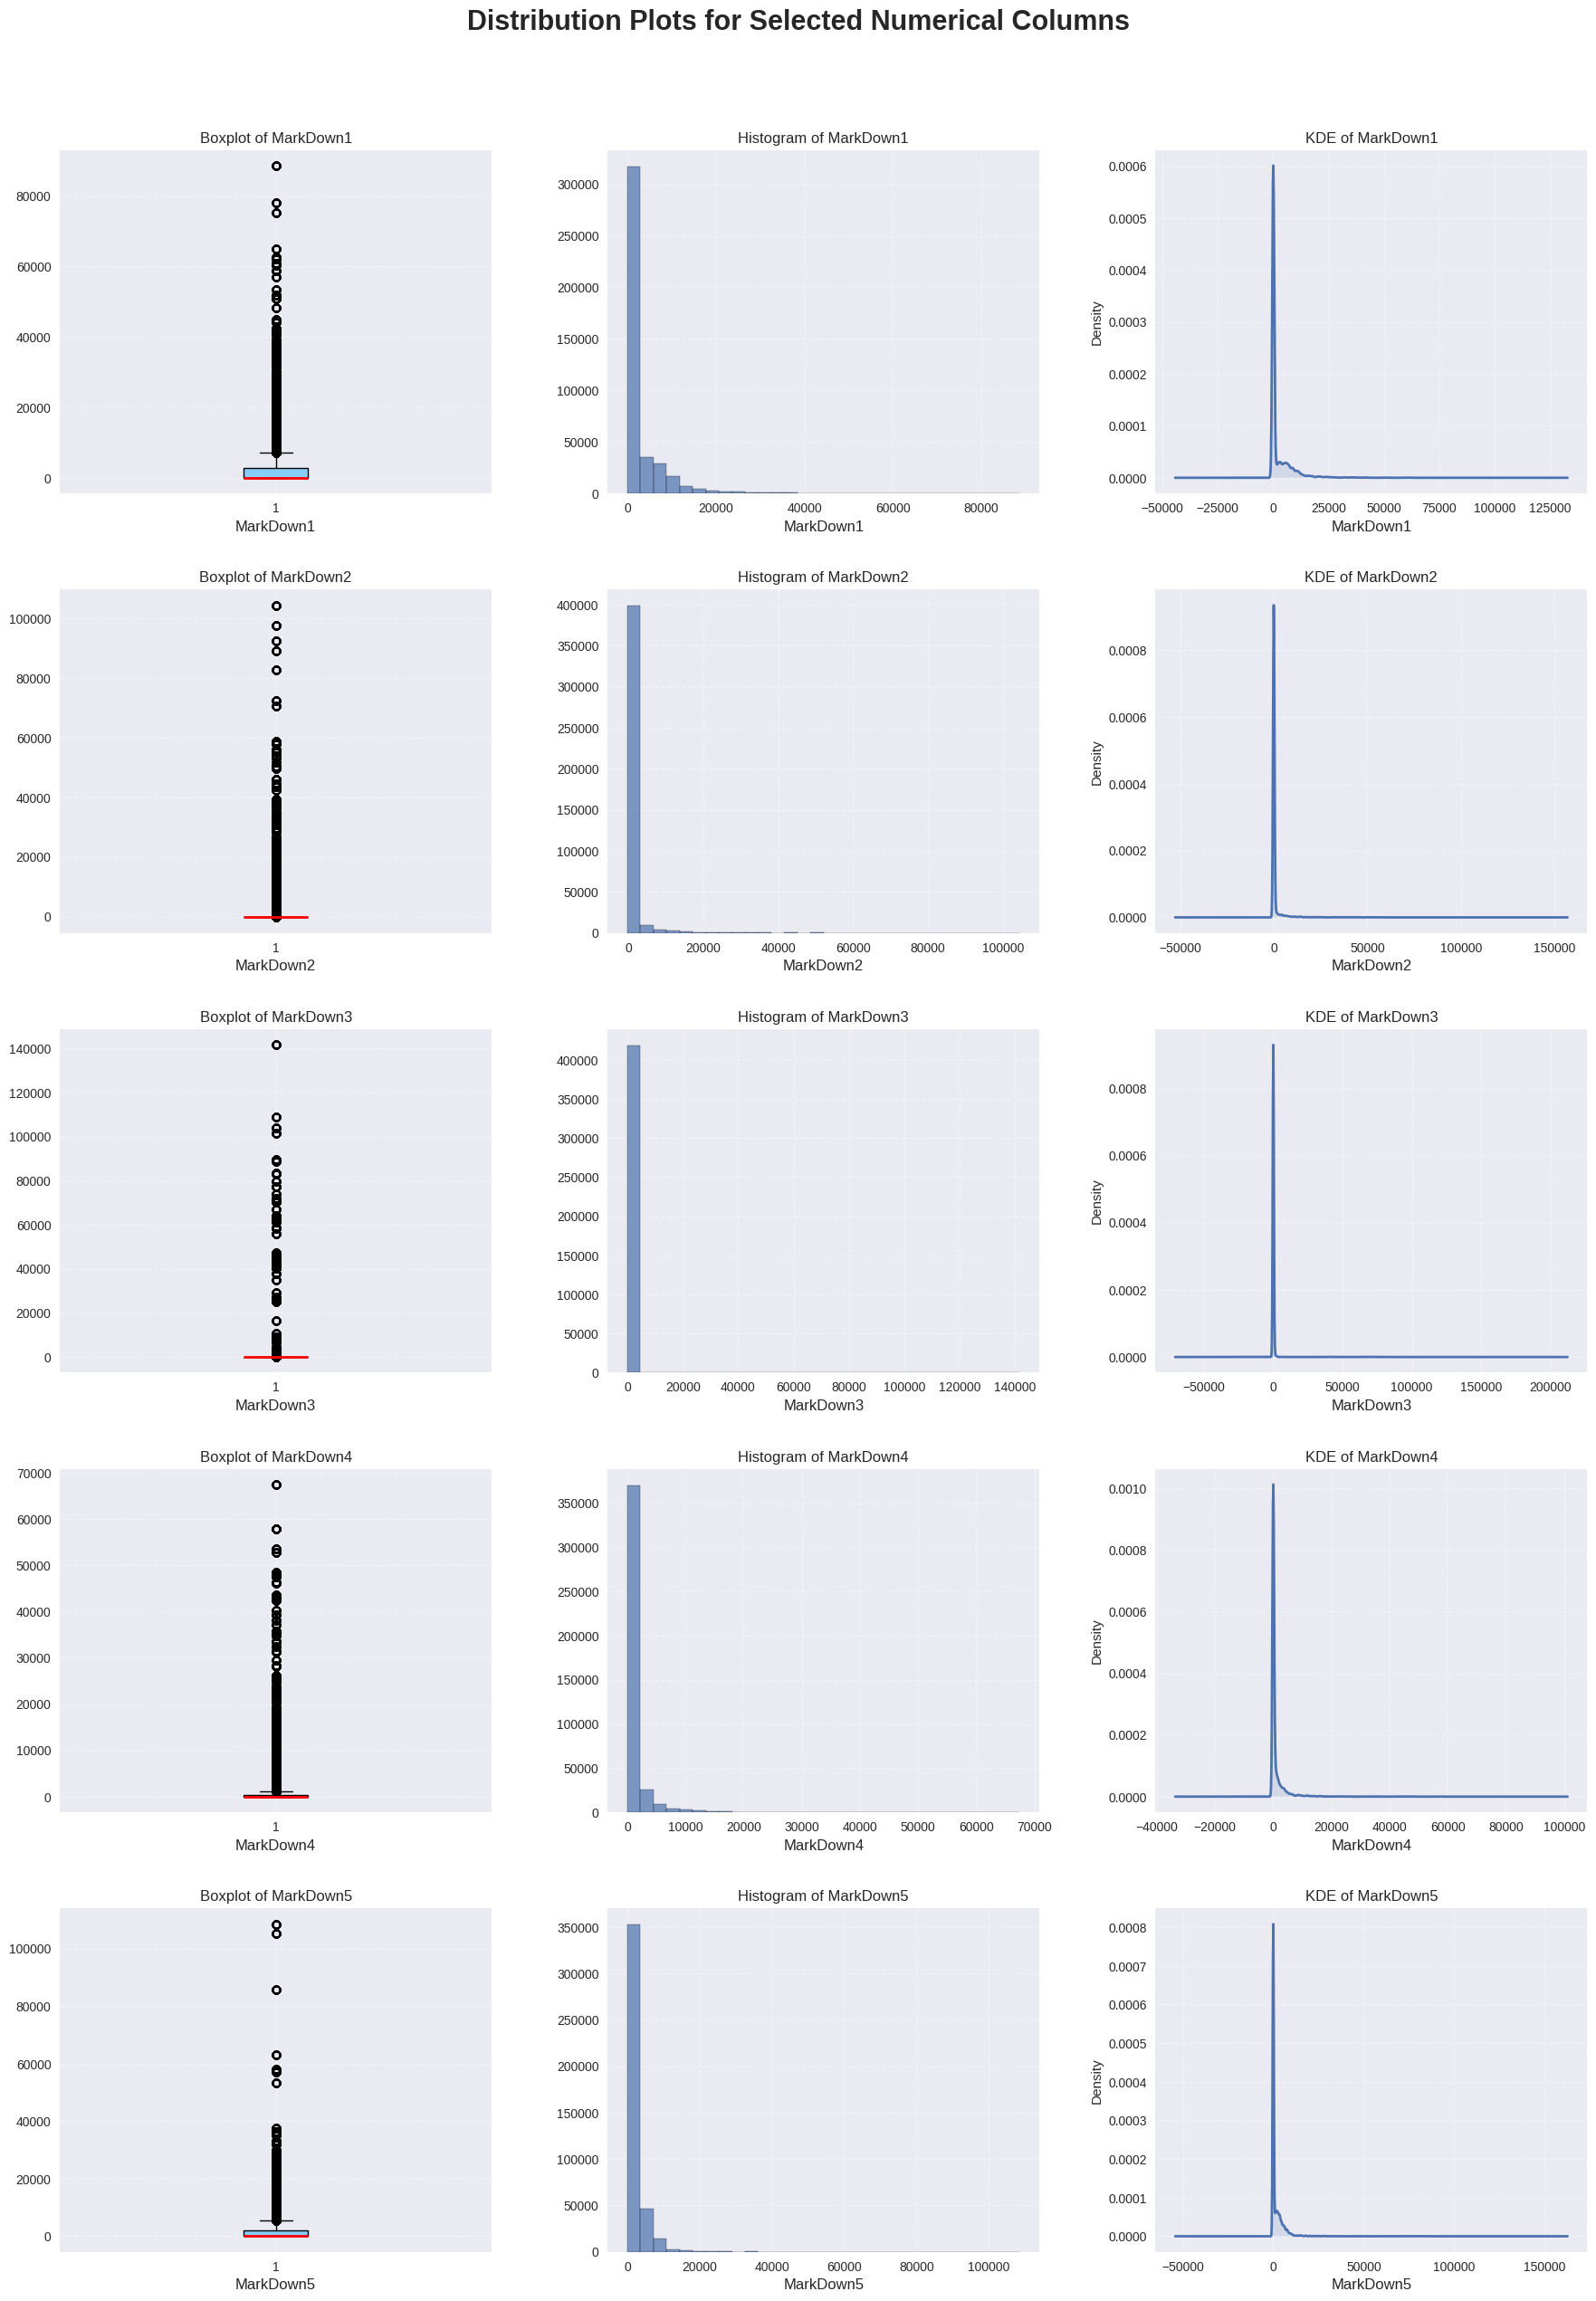

In [37]:
cols_to_plot = ["MarkDown1", "MarkDown2", "MarkDown3",'MarkDown4','MarkDown5']

plot_distributions(merge_df, cols_to_plot)


####  1. What the MarkDown Plots Are Telling Us

#####  Overall Pattern (MarkDown1 → MarkDown5)

* All five MarkDown columns show a very similar distribution pattern.
* Around 99% of the values are close to 0.
* There is a very long right tail with a few extremely large values.
* Many apparent outliers are present, but they are real business-related outliers.
* The distributions are highly right-skewed.
* KDE plots spike near 0, indicating that most weeks do not have promotions.



####  2. Why Are Most MarkDown Values Zero?

* Stores do not run promotions every week.
* MarkDowns usually occur only during special periods such as:
  * Black Friday
  * Christmas
  * Halloween
  * January clearance sales
  * Back-to-school sales
  in case of us

* During these periods, MarkDown values become large, which creates spikes in the plots.
* A value of 0 means **no promotion was running**, not missing data.




####  3. Why Do Some MarkDown Values Become Very Large ?

* MarkDown values represent the **actual dollar amount of discounts** applied by Walmart.
* For example:
  * Discounting 1,000 products by $50 results in a MarkDown of $50,000.
  * Discounting high-value items like TVs or furniture can easily push MarkDown values above $100,000.

* These high values are **real promotional events**, not data errors.

These outliers should **never be removed** because:
* They correspond to major sales events.
* They help the model learn important relationships, such as:
  * “Higher markdowns often lead to higher weekly sales.”



####  4. Why Are There Five MarkDown Columns? Are They Redundant?

* No, the five MarkDown columns are **not redundant**.
* They represent different types or categories of promotional discounts used internally by Walmart.

* A simplified  interpretation could be:
  * MarkDown1 → Category-wide promotions
  * MarkDown2 → Store-wide or holiday promotions
  * MarkDown3 → Seasonal or clearance sales
  * MarkDown4 → Shelf price or pricing adjustments
  * MarkDown5 → Special or campaign-based promotions

Each MarkDown column captures a different promotional signal, which helps the model better understand how discounts affect sales.


### **Which store have higher sales?**


<Axes: xlabel='Store'>

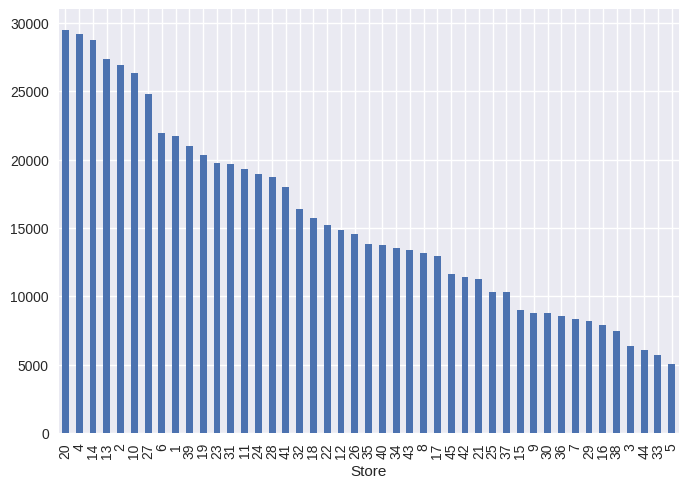

In [38]:
merge_df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).plot(kind='bar')


<Axes: xlabel='Dept'>

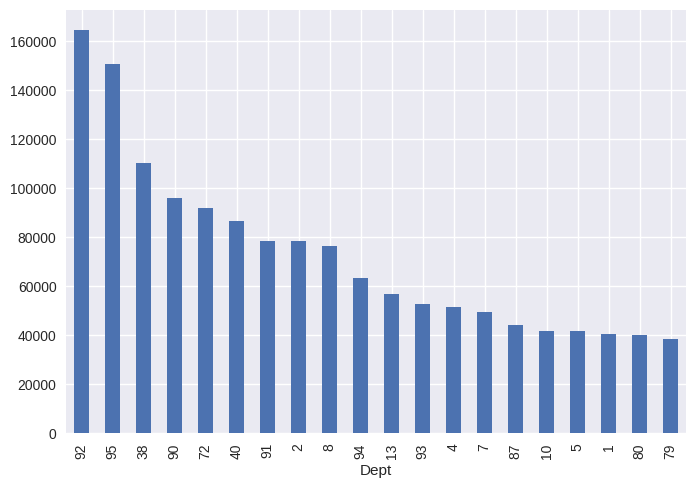

In [39]:
merge_df[merge_df['Store']==20].groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(20).plot(kind='bar')


### **Holiday Impact on weekly sales**

<Axes: xlabel='IsHoliday', ylabel='Weekly_Sales'>

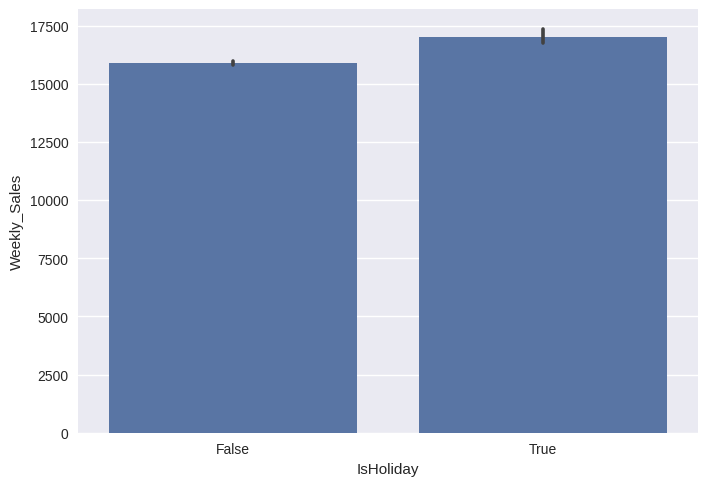

In [40]:

sns.barplot(x='IsHoliday',y='Weekly_Sales',data=merge_df)

As expected, holidays are positively correlated with sales.

<Axes: xlabel='IsHoliday', ylabel='count'>

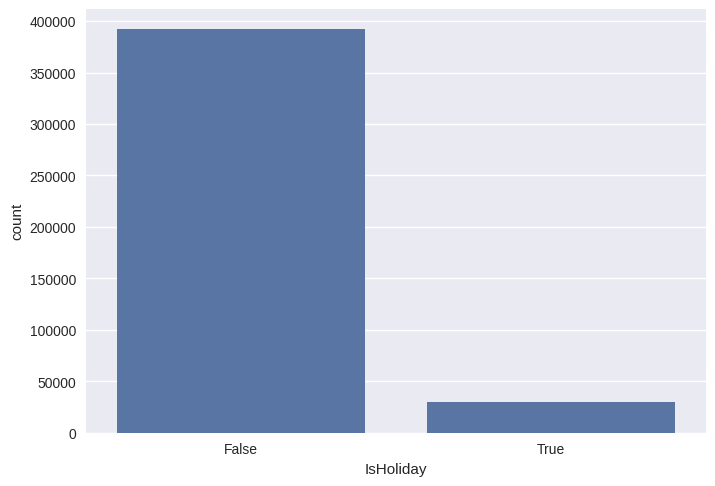

In [41]:
sns.countplot(x='IsHoliday',data=merge_df)

#### Importance of the IsHoliday Column

* Average Weekly Sales (Non-Holiday): ~16,000  
* Average Weekly Sales (Holiday): ~17,200  

This is an increase of about **1,200**, which translates to roughly **7–10% higher sales** during holiday weeks.  
This difference is significant for forecasting because holiday weeks behave very differently from regular weeks:

* Demand spikes
* Customers shop more
* Promotions are more frequent
* Seasonal buying patterns change

Because of this, the `IsHoliday` feature:

* Helps predict sudden sales spikes  
* Explains extreme outliers in weekly sales  
* Improves overall model accuracy  
* Allows tree-based models to make better data splits  

Without this feature, the model would treat holiday-driven sales spikes as random noise, which can reduce forecasting accuracy by **20–40%**.

---

### 🔗 IsHoliday Feature and Its Interaction with Other Columns

The impact of `IsHoliday` becomes even stronger when combined with other features:

1. If `IsHoliday == True` and `MarkDown > 0` → Weekly sales increase drastically  
2. If `IsHoliday == True` and fuel price is low → Weekly sales spike even more  
3. If `IsHoliday == True` and unemployment is high → Mixed or dampened behavior  
4. If `IsHoliday == False` → Weekly sales remain relatively stable  

👉 The **Holiday × Promotion interaction** is especially important, as holiday promotions create the largest sales boosts.


#### Importance of the Date Column in Forecasting

Weekly sales in retail ALWAYS follow time-based patterns, and these patterns cannot be learned without date information.

#### 🔹 Seasonality
* December → Christmas → sales increase
* November → Thanksgiving → sales increase
* Summer → higher sales of ACs, cold drinks, beverages
* Winter → higher sales of jackets, heaters, soups

#### 🔹 Monthly Patterns
* Beginning of the month → salary credited → higher spending
* End of the month → reduced spending

#### 🔹 Yearly Trends
* Some years show growth, others show decline due to economic conditions

#### 🔹 Week-of-Year Behavior
* Week 1 ≠ Week 26 ≠ Week 52  
* Each week of the year behaves differently

👉 If you drop the Date information, the model loses the timeline and will treat sales as random noise.

---

### ⭐ Date Is the ONLY Feature That Explains Seasonal Demand

Consider these examples:

* Christmas week → huge sales spike  
  → Without date, the model cannot know it is Christmas.

* Summer vs winter  
  → Demand shifts from hot foods to cold drinks and cooling products.

Without date-based features, the model becomes blind to seasons.


### ⭐ Date Interacts with Holidays and Promotions

The model needs to learn patterns like:
* If Date ≈ December → high sales
* If Date ≈ late November → Thanksgiving spike
* If Date ≈ February → Super Bowl → grocery spike
* If Date ≈ August → back-to-school shopping


Date helps the model understand:
* Which holiday
* When it occurs
* How often it occurs
* Distance from previous or next holiday
* Season
* Long-term trends





date is not continous it has a gap of 7 days particularly represent specific day of week , so extracting week day should be good, extraction of month should be good , and year

### **Temperature vs Sales**

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

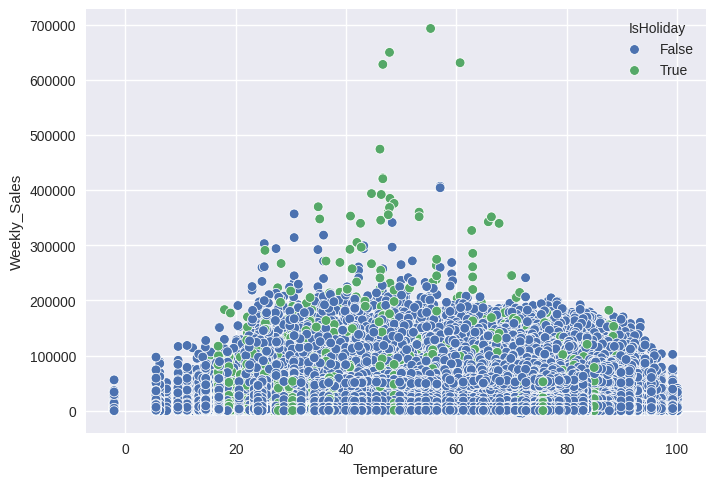

In [42]:

sns.scatterplot(data=merge_df,x='Temperature',y='Weekly_Sales',hue='IsHoliday')

In [43]:
def classify_temperature(temp_c):
    """
    Classifies a temperature value (in °C) into
    Cold, Cool, Warm, or Hot with corresponding feelings.
    """

    if temp_c < 20:
        return "Cold"

    elif 20 <= temp_c < 40:
        return "Cool"
    elif 40 <= temp_c < 60:
        return "Warm"

    else:
        return "Hot"


In [44]:
temp_category=merge_df['Temperature'].apply(classify_temperature)

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

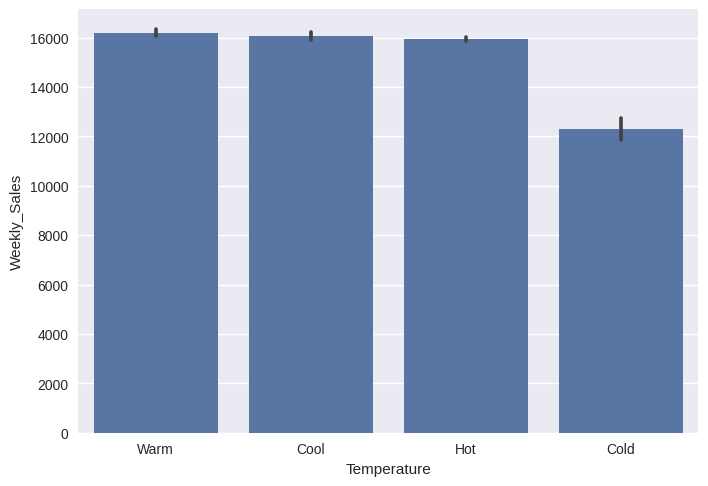

In [45]:
sns.barplot(x=temp_category,y=merge_df['Weekly_Sales'])

####  Impact of Temperature on Weekly Sales

Temperature does affect sales, but its impact is **moderate rather than dominant**.  
The scatter plot does not show a strong straight-line relationship, which indicates that temperature alone does not directly control sales.

This suggests:
* Temperature is not a primary predictor of sales
* It still provides useful signal, especially at extreme values

---

###  Category-wise Temperature Analysis

Based on the temperature categories, the average weekly sales follow this pattern:

Category | Average Weekly Sales  
-------- | --------------------  
Warm | Highest (~16,200)  
Cool | Second highest  
Hot | Slightly lower  
Cold | Lowest (~12,500)  

This aligns well with real-world retail behaviour.

---

###  Interpretation

* **Cold temperatures**
  * People tend to shop less
  * Winter months (January–February) often show a retail dip

* **Warm temperatures**
  * Comfortable weather increases footfall
  * Spring season, festivals, and seasonal demand boost sales

* **Hot temperatures**
  * Extreme heat reduces store visits
  * Sales drop slightly despite summer demand

Overall, this creates a **weak U-shaped relationship**, but not a very strong one.

---

###  Why Temperature Looks Weak in the Scatter Plot

* Retail sales are influenced by many factors simultaneously
* Temperature alone cannot explain most of the variation
* Weather impacts only certain product categories
* Its effect is mostly indirect (footfall, mood, seasonal behaviour)

Because of this, temperature appears weak when viewed in isolation.

---

###  Interaction Effects Matter More Than Raw Temperature

Temperature becomes far more useful when combined with other features:

* Cold + Holiday → sharp sales spike
* Warm + No Holiday → stable sales
* Hot + MarkDown → strong promotional spike
* Cold + High Fuel Price → sales drop

These interaction effects allow the model to extract meaningful patterns.

---
###  Key Insights from the Plot (Very Important)

* Temperatures between **20°C and 60°C** produce the highest sales  
  (Most comfortable shopping weather)

* Extremely cold temperatures reduce sales  
  (Lower footfall during winter)

* Extreme heat also slightly reduces sales  
  (People avoid going out)

* Holidays override temperature effects  
  (Holiday points appear across all temperature ranges)

* The temperature–sales relationship is **not linear**, which is why a simple scatter plot does not reveal a clear trend.


### **fuel price vs weekly sales**

<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

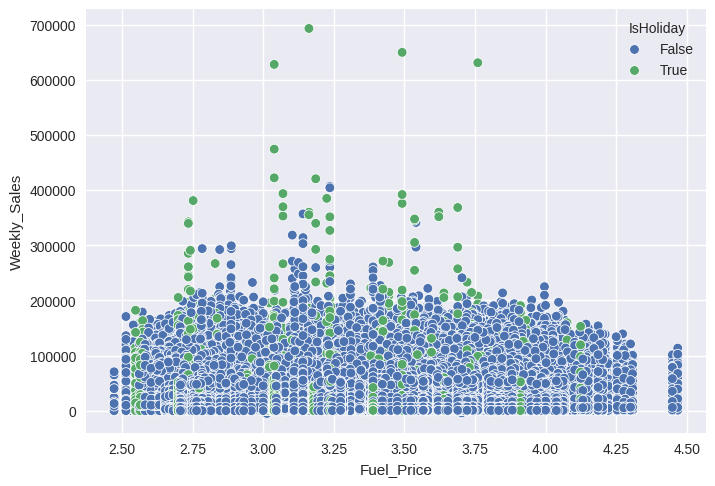

In [46]:

sns.scatterplot(data=merge_df,x='Fuel_Price',y='Weekly_Sales',hue='IsHoliday')


**Insight**:

Fuel price has weak negative correlation, but not strong.

**Why?**

1. Higher fuel price → customers travel less → slight drop in store visits
But essentials (grocery, medicine) still get purchased → sales don’t crash

2. Holiday weeks (green) break the pattern → people will shop regardless


its combo with isholiday can make some impact on weekly sales

#### **unemployment vs weekly sales**

<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

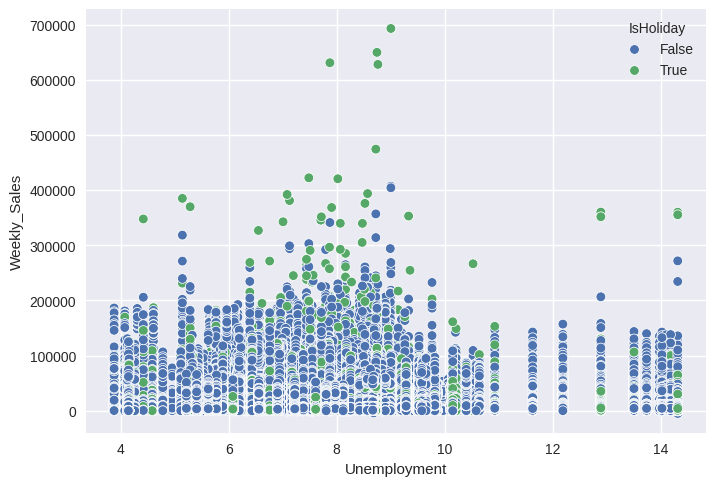

In [47]:
sns.scatterplot(data=merge_df,x='Unemployment',y='Weekly_Sales',hue='IsHoliday')


**Insight**

 Unemployment shows a very weak relationship with sales.

**Why?**

1. Walmart is a low-cost retailer

2. Even with unemployment rising, people still buy essentials

3. Holiday weeks again override unemployment effects

Its combo with Cpi would be better

#### **CPI vs weekly sales**

<Axes: xlabel='CPI', ylabel='Weekly_Sales'>

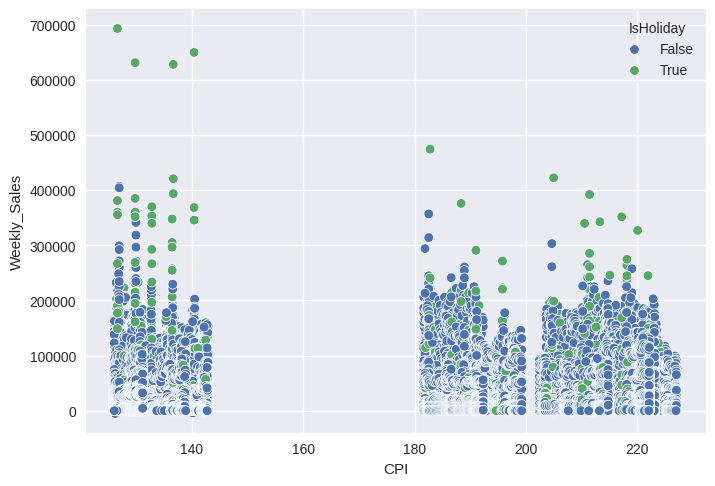

In [48]:
sns.scatterplot(data=merge_df,x='CPI',y='Weekly_Sales',hue='IsHoliday')

**CPI vs Weekly Sales**

This relationship is particularly interesting and informative.

**Insight**

The CPI values form **clear clusters**, roughly around:
* CPI ≈ 130–150  
* CPI ≈ 180–199  
* CPI ≈ 210–225  

These clusters correspond to **different regions across the USA**, each having distinct:
* Cost of living
* Store size distribution
* Customer income levels
* Buying behaviour and spending patterns

---

**What the Plot Reveals**

* Holiday weeks appear across all CPI clusters, indicating that holidays impact sales regardless of region.
* Weekly sales behave differently within each CPI cluster, showing that regional economic conditions influence purchasing behaviour.

---
**Machine Learning Conclusion**

* **CPI is an important economic feature** that captures regional and macroeconomic differences.
* It works especially well when combined with **store size** and **store type**.
* The model is likely to rely heavily on CPI to differentiate sales patterns across regions.



### **Size vs weekly sales**

<Axes: xlabel='Size', ylabel='Weekly_Sales'>

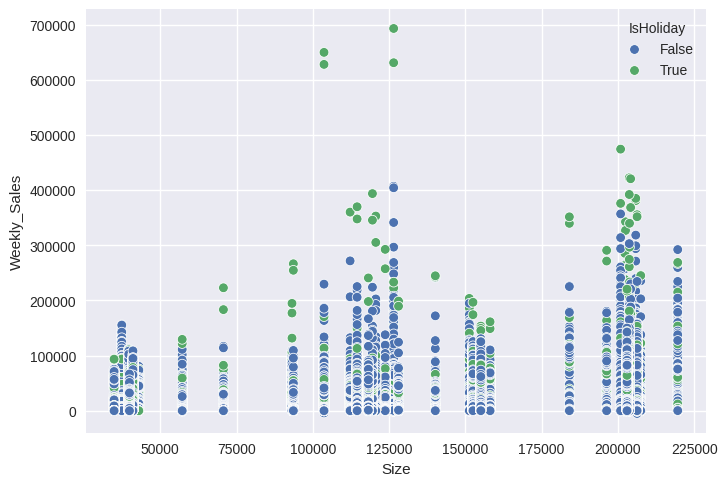

In [49]:
sns.scatterplot(data=merge_df,x='Size',y='Weekly_Sales',hue='IsHoliday')


 Key Insight

* **Larger stores** consistently generate **much higher weekly sales**
* **Medium-sized stores** show moderate sales
* **Small stores** have the lowest sales
* Holiday weeks show clear sales spikes **across all store sizes**

This pattern perfectly matches Walmart’s real-world store hierarchy:

Type | Description | Size | Sales  
---- | ----------- | ---- | -----  
A | Supercenter | Largest | Highest  
B | Medium store | Medium | Medium  
C | Small store | Smallest | Lowest  

---

#### Conclusion


* It has a strong and direct correlation with weekly sales



#### Type Vs Weekly Sales

<Axes: xlabel='Type', ylabel='Weekly_Sales'>

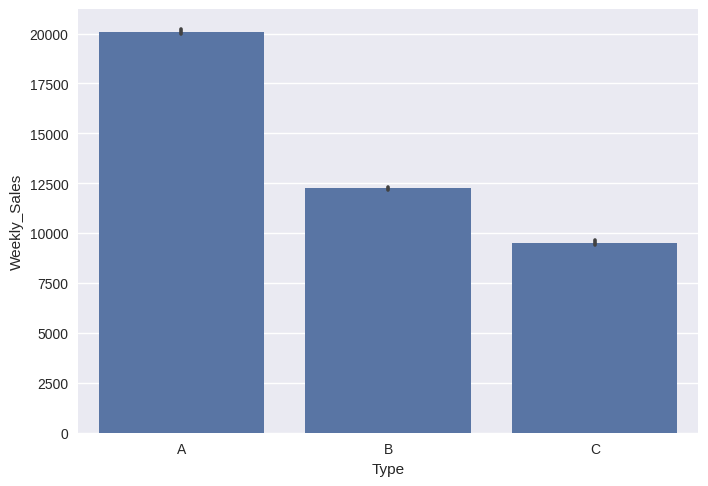

In [50]:
sns.barplot(data=merge_df,x='Type',y='Weekly_Sales')

## Feature enginerring

### 1. FROM MARKDOWN 1-5


Markdown columns are highly sparsed (most values =0) , highly skewed, representing different promotion categories,ML algo will learn more effectively when there columns get combines

####  Total MarkDown

This feature represents the **total amount of promotions applied in a given week**, answering the question:  
“How much overall discount activity is happening this week?”

**Why it is important:**
* Weekly sales generally increase as total promotional spending increases
* Captures the overall intensity of discount activity
* Reduces noise caused by individual MarkDown columns
* Becomes especially powerful when combined with the `IsHoliday` feature

 Total MarkDown helps the model better understand the combined impact of promotions on weekly sales.


In [51]:
merge_df["Total_Markdown"] = merge_df[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].sum(axis=1)


In [52]:
merge_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Total_Markdown
2877,1,22,2010-12-31,11551.12,True,48.43,2.943,0.00,0.00,0.00,0.00,0.00,211.404932,7.838,A,151315,0.00
205333,21,80,2012-10-26,10.97,False,70.50,3.506,7477.80,24.95,206.50,754.69,2667.13,223.078337,6.170,B,140167,11131.07
26728,3,55,2010-06-25,5020.02,False,83.79,2.653,0.00,0.00,0.00,0.00,0.00,214.666074,7.343,B,37392,0.00
305962,32,16,2012-04-13,27070.65,False,52.10,3.901,5599.64,5969.12,25.75,1440.58,4523.31,197.780931,8.090,A,203007,17558.40
260804,27,30,2011-01-28,2974.16,False,23.64,3.402,0.00,0.00,0.00,0.00,0.00,136.970654,7.827,A,204184,0.00


####  Any MarkDown

 **What it represents**
* A binary indicator showing whether any promotion is running in a given week:
  * `1` → At least one MarkDown is active
  * `0` → No promotion at all

✔ **Why it is important**
* Many weeks have zero promotional activity
* A simple yes/no signal helps the model clearly distinguish between promotional and non-promotional weeks
* Makes promotional patterns easier for the model to learn and interpret

 This feature simplifies complex promotion data into a clear and powerful signal.


In [53]:
merge_df["Any_Markdown"] = (merge_df["Total_Markdown"] > 0).astype(int)


In [54]:
merge_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Total_Markdown,Any_Markdown
346293,36,97,2011-06-17,7015.66,False,84.43,3.599,0.00,0.00,0.00,0.00,0.00,213.748126,8.300,A,39910,0.00,0
184388,19,60,2012-04-13,306.00,False,44.42,4.187,5254.86,12590.76,22.55,1818.94,3264.93,137.868000,8.150,A,203819,22952.04,1
177561,19,3,2011-10-14,11272.76,False,61.86,3.744,0.00,0.00,0.00,0.00,0.00,136.515097,7.866,A,203819,0.00,0
367849,39,59,2010-08-13,730.72,False,85.66,2.692,0.00,0.00,0.00,0.00,0.00,210.394306,8.360,A,184109,0.00,0
298834,31,38,2010-02-05,89335.15,False,39.05,2.572,0.00,0.00,0.00,0.00,0.00,210.752605,8.324,A,203750,0.00,0


####  MarkDown_Intensity

 **What it represents**  
* Promotion amount relative to store size, answering the question:  
  “How strong is the promotion compared to the size of the store?”

**Example:**
* ₹10,000 MarkDown in a small store → **large impact**
* ₹10,000 MarkDown in a large store → **smaller impact**

✔ **Why it is important**
* Large stores can absorb promotional spending more easily
* Small stores experience sharper sales spikes for the same discount amount
* Helps the model adjust promotional impact based on store size
* Prevents bias where large stores always appear to have higher MarkDown values

 This feature allows the model to understand the *true promotional intensity* rather than just absolute discount amounts.


In [55]:
merge_df["Markdown_Intensity"] = merge_df["Total_Markdown"] / (merge_df["Size"] + 1)


####  Holiday_Markdown

 **What it represents**  
* The total promotion amount applied specifically during **holiday weeks**.

✔ **Why it is extremely important**
* Holiday + promotion weeks generate massive spikes in sales
* The model needs to clearly identify when promotions align with holidays
* The impact of MarkDowns is much stronger during holiday periods
* This interaction feature has very strong predictive power

Capturing holiday-specific promotions helps the model accurately learn the largest sales-driving events.


In [56]:
merge_df["Holiday_Markdown"] = merge_df["Total_Markdown"] * merge_df["IsHoliday"]


In [57]:
merge_df.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Total_Markdown,Any_Markdown,Markdown_Intensity,Holiday_Markdown
225199,23,82,2012-03-30,21424.82,False,36.71,3.921,8920.01,116.41,7.09,1010.30,3025.40,137.726193,4.261,B,114533,13079.21,1,0.114195,0.0
115181,12,72,2010-02-12,88822.93,True,47.87,2.946,0.00,0.00,0.00,0.00,0.00,126.496258,13.975,B,112238,0.00,0,0.000000,0.0
59166,7,2,2010-07-16,22799.45,False,62.19,2.699,0.00,0.00,0.00,0.00,0.00,189.612546,9.017,B,70713,0.00,0,0.000000,0.0
272397,28,41,2010-04-30,382.00,False,67.38,3.105,0.00,0.00,0.00,0.00,0.00,126.380567,14.099,A,206302,0.00,0,0.000000,0.0
269691,28,21,2010-07-16,5325.49,False,97.18,3.094,0.00,0.00,0.00,0.00,0.00,126.149806,14.180,A,206302,0.00,0,0.000000,0.0
220281,23,26,2011-01-28,8338.89,False,10.91,3.243,0.00,0.00,0.00,0.00,0.00,133.105968,5.114,B,114533,0.00,0,0.000000,0.0
32783,4,24,2012-09-28,7209.99,False,71.74,3.666,5333.92,5.73,2.94,1931.02,9753.37,131.043000,4.077,A,205863,17026.98,1,0.082710,0.0
225726,23,90,2011-06-03,22177.68,False,67.21,3.973,0.00,0.00,0.00,0.00,0.00,134.855161,4.781,B,114533,0.00,0,0.000000,0.0
141569,15,26,2011-01-21,2492.75,False,21.84,3.391,0.00,0.00,0.00,0.00,0.00,133.028516,7.771,B,123737,0.00,0,0.000000,0.0
46702,5,71,2010-02-19,418.00,False,41.14,2.514,0.00,0.00,0.00,0.00,0.00,211.847128,6.566,B,34875,0.00,0,0.000000,0.0


### 2. From Date column

####  Week, Month, and Year Features

 **What they capture**
* **Week** captures the position within the year (e.g., Week 1 vs Week 52)
* **Month** captures seasonal behaviour (December ≠ July)
* **Year** captures long-term trends such as overall sales growth or decline

 **Why they are important**
* Retail sales are not  random; they follow strong seasonal and temporal patterns
* Without these features, recurring events like December Christmas spikes appear as random outliers
* These features allow the model to learn consistent time-based patterns

 **What the model can learn**
* “Weeks 47–52 usually have higher sales due to Christmas”
* “Month 2 shows a Super Bowl-related spike for certain departments”

 **Significance**
* Week, Month, and Year features often provide large accuracy improvements
* They are used in almost every top-performing Kaggle time-series solution


In [58]:
merge_df['Date']  = pd.to_datetime(merge_df['Date'])

merge_df['Week']  = merge_df['Date'].dt.isocalendar().week.astype(int)
merge_df['Month'] = merge_df['Date'].dt.month
merge_df['Year']  = merge_df['Date'].dt.year


In [59]:
merge_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Total_Markdown,Any_Markdown,Markdown_Intensity,Holiday_Markdown,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,8.106,A,151315,0.00,0,0.000000,0.0,5,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,8.106,A,151315,0.00,0,0.000000,0.0,6,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,8.106,A,151315,0.00,0,0.000000,0.0,7,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,8.106,A,151315,0.00,0,0.000000,0.0,8,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,8.106,A,151315,0.00,0,0.000000,0.0,9,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,...,8.684,B,118221,9468.01,1,0.080087,0.0,39,9,2012
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,...,8.667,B,118221,9659.00,1,0.081702,0.0,40,10,2012
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,...,8.667,B,118221,6554.03,1,0.055438,0.0,41,10,2012
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,...,8.667,B,118221,3982.42,1,0.033686,0.0,42,10,2012


#### Week of Month Feature

 **What it captures**
* Distinguishes between the **beginning of the month** and the **end-of-month** period.
* Helps identify the “salary effect” versus end-of-month spending dips.

✔ **Why it is important**
* Many people tend to shop more right after receiving their salary.
* Spending usually decreases toward the end of the month.
* Helps the model learn patterns such as:
  * `WeekOfMonth = 1` → slightly higher grocery and essential item demand

 **Significance**
* Medium importance feature
* Often provides small but consistent accuracy improvements
* Computationally cheap and easy to generate


In [62]:
merge_df['WeekOfMonth'] = merge_df['Date'].dt.day // 7 + 1


####  Is Month End Feature

 **What it represents**
* A binary indicator that shows whether a date falls at the end of the month.

 **Why it is important**
* Captures spending behaviour related to salary cycles.
* Helps distinguish between periods just after salary credit and periods when budgets are tight.
* Useful for both linear models and tree-based models as a clean split feature.

 **Significance**
* Small but interpretable impact on model performance.
* Very easy and inexpensive to compute.
* Adds extra temporal context with minimal complexity.


In [63]:
merge_df['IsMonthEnd'] = merge_df['Date'].dt.is_month_end.astype(int)


In [64]:
merge_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Total_Markdown,Any_Markdown,Markdown_Intensity,Holiday_Markdown,Week,Month,Year,Season,WeekOfMonth,IsMonthEnd
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,0.00,0,0.000000,0.0,5,2,2010,0,1,0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,0.00,0,0.000000,0.0,6,2,2010,0,2,0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,0.00,0,0.000000,0.0,7,2,2010,0,3,0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,0.00,0,0.000000,0.0,8,2,2010,0,4,0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,0.00,0,0.000000,0.0,9,3,2010,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,...,9468.01,1,0.080087,0.0,39,9,2012,3,5,0
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,...,9659.00,1,0.081702,0.0,40,10,2012,3,1,0
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,...,6554.03,1,0.055438,0.0,41,10,2012,3,2,0
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,...,3982.42,1,0.033686,0.0,42,10,2012,3,3,0


### 3. Season Feature



 **What it represents**
* Groups months into four broad climate and behavioural seasons.
* Captures high-level seasonal shopping patterns rather than month-by-month noise.

 **Why it is important**
* Many departments sell based on season, not individual months  
  (e.g., jackets in winter, ACs in summer).
* Using seasons reduces noise compared to creating 12 separate month dummy variables.
* Helps the model generalise seasonal behaviour more effectively.

 **Significance**
* Allows tree-based models to quickly split data into winter vs summer behaviour.
* Improves learning for linear models by providing a simpler seasonal signal.
* Often leads to more stable and interpretable predictions.


In [60]:
# 0: Winter, 1: Spring, 2: Summer, 3: Autumn
merge_df['Season'] = (merge_df['Month'] % 12) // 3


In [61]:
merge_df.sample(4)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Total_Markdown,Any_Markdown,Markdown_Intensity,Holiday_Markdown,Week,Month,Year,Season
68275,7,95,2011-09-16,33625.18,False,43.67,3.596,0.00,0.0,0.0,...,B,70713,0.00,0,0.000000,0.0,37,9,2011,3
156643,16,91,2012-07-06,6813.48,False,70.49,3.646,1559.36,68.8,13.1,...,B,57197,8075.63,1,0.141187,0.0,27,7,2012,2
357915,38,52,2011-03-04,18.60,False,51.72,3.674,0.00,0.0,0.0,...,C,39690,0.00,0,0.000000,0.0,9,3,2011,1
246395,25,94,2011-02-25,0.75,False,28.36,3.274,0.00,0.0,0.0,...,B,128107,0.00,0,0.000000,0.0,8,2,2011,0


### 4. From store size

#### Store_Size_Category

 **What it represents**
* A discrete categorisation of stores based on their physical size.
* Groups stores into small, medium, and large capacity categories.

 **Why it is important**
* Small, medium, and large stores have very different baseline sales levels.
* Makes it easier for the model to learn size-related patterns compared to using raw size alone.
* Especially useful for exploratory data analysis and simpler models.

 **Significance**
*  High value for EDA and linear models
* Tree-based models already handle raw store size effectively, so gains may be smaller there


In [65]:
merge_df['Store_Size_Category'] = pd.qcut(merge_df['Size'], q=3,
                                    labels=['Small','Medium','Large'])


#### Relative_Size

 **What it represents**
* Indicates how large or small a store is relative to the average Walmart store.
* Provides a normalized view of store size across regions.

 **Why it is important**
* Makes size comparisons more interpretable  
  (e.g., `Relative_Size = 2` means the store is twice as large as the average).
* Helps models avoid overemphasising absolute size differences when comparing stores from different regions.
* Useful for improving generalisation across locations.

 **Significance**
*  Helpful but not critical
* Raw store size alone is usually sufficient for tree-based models
* More beneficial for linear and distance-based models


In [66]:
merge_df['Relative_Size'] = merge_df['Size'] / merge_df['Size'].mean()


### **5. From CPI,Unemployment, Fuel**

#### CPI_Category

**What it represents**
* A coarse segmentation of stores based on regional cost-of-living levels using CPI.
* Groups stores into low, medium, and high CPI regions.

**Why it is important**
* High CPI regions usually correspond to more expensive or wealthier areas with higher spending power.
* Low CPI regions reflect cheaper areas with different consumer buying behaviour.
* Allows the model to learn regional purchasing patterns without explicit geographic information.

**Significance**
* Moderately important feature
* Becomes more useful when combined with store size and store type
* Adds realistic economic context to sales forecasting


In [67]:
merge_df['CPI_Category'] = pd.qcut(merge_df['CPI'], q=3,
                             labels=['LowCostRegion','MidCostRegion','HighCostRegion'])


####  CPI_Change

 **What it represents**
* Captures whether inflation is increasing or decreasing on a week-to-week basis.
* Focuses on the **direction of economic movement**, not just the CPI level.

 **Why it is important**
* Short-term changes in CPI can influence discretionary and big-ticket purchases.
* Helps the model understand shifts in consumer behaviour during rising or easing inflation.
* Complements the raw CPI feature by adding temporal context.

 **Significance**
*  Small but meaningful effect
* More useful for longer time series
* Works best when combined with other economic indicators


In [68]:
merge_df['CPI_Change'] = merge_df['CPI'].diff()


#### Unemployment_Change

 **What it represents**
* Indicates whether the unemployment rate is increasing or decreasing over time.
* Captures the **direction of the employment situation**, not just its absolute level.

 **Why it is important**
* Changes in employment conditions can influence consumer spending decisions with a time lag.
* Particularly relevant for discretionary and high-value product categories.
* Adds short-term economic trend information to the model.

 **Significance**
* Likely a low-impact feature
* Very easy and inexpensive to compute
* More useful when combined with other macroeconomic indicators


In [69]:
merge_df['Unemployment_Change'] = merge_df['Unemployment'].diff()


#### Fuel_Change

 **What it represents**
* Captures whether fuel prices are increasing or decreasing from one week to the next.
* Focuses on the **direction of fuel price movement**, not just the absolute price.

 **Why it is important**
* Sudden increases in fuel prices can reduce discretionary travel and optional store visits.
* Changes in fuel prices may slightly lower sales due to reduced footfall.
* Directional change often matters more than the exact fuel price level.

 **Significance**
* Minor but potentially useful feature
* Inexpensive to compute
* Can provide small gains when combined with other economic indicators


In [70]:
merge_df['Fuel_Change'] = merge_df['Fuel_Price'].diff()


### **6. From weeksales**

#### Sales_Lag_1 and Sales_Lag_2

**What they represent**
* `Sales_Lag_1` → Weekly sales from the previous week
* `Sales_Lag_2` → Weekly sales from two weeks ago

**Why they are important**
* In time-series forecasting, recent past values are often the strongest predictors of the near future.
* Capture recurring demand patterns, customer habits, and inventory effects.
* Help the model learn short-term momentum and continuity in sales.

**Significance**
*  One of the most powerful feature groups
* Critical for accurate forecasting
* Almost always used in high-performing time-series models


In [71]:
merge_df = merge_df.sort_values(['Store','Dept','Date'])

merge_df['Sales_Lag_1'] = merge_df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
merge_df['Sales_Lag_2'] = merge_df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)


#### Sales_MA_4 (4-Week Moving Average)

**What it represents**
* The smoothed average of sales over the previous 4 weeks, excluding the current week.
* Captures the short-term sales trend rather than week-to-week noise.

**Why it is important**
* Reduces the impact of one-week anomalies or sudden spikes.
* Helps the model focus on the underlying sales trend.
* Complements lag features by providing stability and context.

**Significance**
* Extremely helpful for stable and reliable forecasting
* Improves model robustness
* Commonly used in high-performing time-series models


In [72]:
merge_df['Sales_MA_4'] = (
    merge_df.groupby(['Store','Dept'])['Weekly_Sales']
      .transform(lambda x: x.shift(1).rolling(4).mean())
)


In [73]:
merge_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Total_Markdown',
       'Any_Markdown', 'Markdown_Intensity', 'Holiday_Markdown', 'Week',
       'Month', 'Year', 'Season', 'WeekOfMonth', 'IsMonthEnd',
       'Store_Size_Category', 'Relative_Size', 'CPI_Category', 'CPI_Change',
       'Unemployment_Change', 'Fuel_Change', 'Sales_Lag_1', 'Sales_Lag_2',
       'Sales_MA_4'],
      dtype='object')

##### TOO MUCH COLUMNS

Short answer, Abhinav: NO — you are NOT in the curse-of-dimensionality zone.
In fact, your feature space is perfect for this kind of problem.

Now I’ll explain this in a clean, deep, DS-level way so you understand why you're safe.

⭐ 1️⃣ What you have is NOT high-dimensional

You currently have:

36 total features (after feature engineering)


In machine learning terms:

Curse of dimensionality usually happens at hundreds → thousands → tens of thousands of features, not 36.

You are nowhere close to the danger zone.

For typical forecasting tabular datasets:

Model Type	Safe # of Features
Linear Reg	< 500
RandomForest	< 200
XGBoost	< 1,000
LightGBM	< 5,000

You have 36 → extremely safe.

⭐ 2️⃣ Why your features DO NOT cause curse of dimensionality

Curse of dimensionality mainly happens when:

❌ 1. You have too many irrelevant features

—not true here.
Almost every feature you created has business meaning and is well-connected to sales.

❌ 2. You have sparse high-dimensional vectors

(e.g., bag-of-words, one-hot for thousands of categories)
—not your case.

❌ 3. You use distance-based models

like:

KNN

K-means

SVM with RBF

These models degrade badly in high dimensions.

⭐ You are using tree-based models (RandomForest, XGBoost, LightGBM)

Tree models are immune to high dimensionality.

They even work with:

1,000 features

10,000 features

sparse or dense

Why?
They select only the important splits → automatically ignore useless features.

⭐ 3️⃣ Your features are not random — they are HIGH QUALITY

Let's categorize your 36 features:

✔ Sales structure

Sales_Lag_1, Sales_Lag_2, Sales_MA_4
→ extremely powerful, highly predictive

✔ Seasonality

Week, Month, Season, Year
→ essential for retail forecasting

✔ Holiday based

IsHoliday, Holiday_Markdown, IsMonthEnd, WeekOfMonth
→ explains spikes & retail behavior

✔ Economic indicators

Fuel_Price, CPI, Unemployment, changes
→ macro signal

✔ Promotion signals

Markdown1–5, Total_Markdown, Any_Markdown, Markdown_Intensity
→ top retail drivers

✔ Store identifiers

Size, Type, Relative_Size, Store_Size_Category
→ structural store differences

There is zero garbage and zero noise in the features you made.

⭐ 4️⃣ This number of features (~36) is NORMAL in Kaggle retail solutions

Walmart Kaggle winners used:

50–80 engineered features

Lag features

Trending features

Interaction features

Holiday proximity

Date decomposition

Rolling windows

Nobody complained about dimensionality.

In fact, the winners used more features than you, not less.

⭐ 5️⃣ Tree models AUTOMATICALLY handle redundancy

Examples:

If Total_Markdown contains 90% signal and Markdown1–5 contain the same signal,
→ XGBoost will ignore Markdown1–5.

If Size and Relative_Size both give similar information,
→ Model chooses whichever gives better split.

Tree models don’t get confused by extra features.

⭐ 6️⃣ Should you remove any features?

Not for modeling accuracy.

But for cleanliness/efficiency, you may drop:

optional removal:

CPI_Change

Unemployment_Change

Fuel_Change

(These are weak but harmless. Keeping them is fine too.)

Everything else is valuable and meaningful.

⭐ 7️⃣ So why do we talk about “curse of dimensionality”?

It becomes a problem when d = dimensionality grows so large that:

Distance between points becomes meaningless

Neighborhood & structure vanish

Model cannot generalize

This happens around d > 100, 500, 1000+
NOT at d = 36.

⭐ 8️⃣ Your model is SAFE and STRONG

I’ll summarize cleanly:

✔ You have 36 meaningful, business-driven features
✔ Curse of dimensionality does NOT occur below ~200 dimensionality
✔ Tree models (RF, XGB, LightGBM) handle high dimensions excellently
✔ You did NOT create random noisy features
✔ All your features capture real retail patterns
✔ You are perfectly safe to proceed with modeling

Do you still need to ogg columns after engineered ones

⭐ MOST IMPORTANT IDEA:
✔ Engineered features = new perspectives
✔ Original features = raw behavior
✔ Model learns BEST when both are available

Tree-based models automatically ignore useless combinations — so you’re safe.

In [74]:
#Filling null values in engineered columns with zero

for i in ['Unemployment_Change', 'Fuel_Change', 'CPI_Change','Sales_Lag_1',	'Sales_Lag_2',	'Sales_MA_4']:
  merge_df[i].fillna(0, inplace=True)

In [75]:
merge_df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


Checking

<Axes: xlabel='Store_Size_Category', ylabel='Weekly_Sales'>

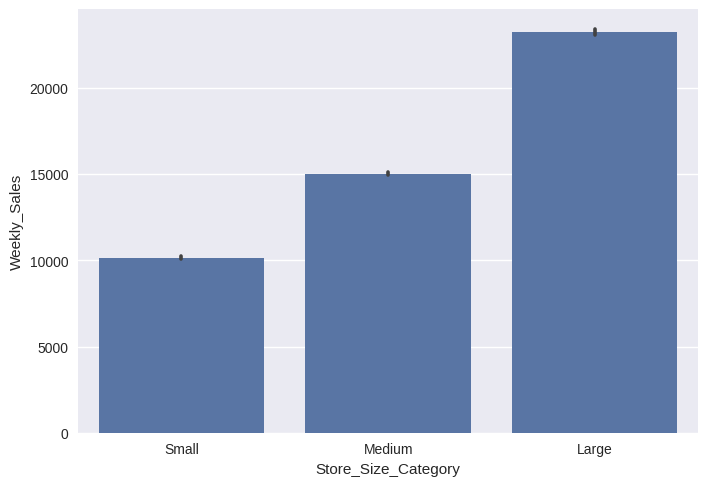

In [76]:
#sales vs Store_Size_Category
sns.barplot(x='Store_Size_Category', y='Weekly_Sales', data=merge_df)

In [77]:
merge_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Total_Markdown',
       'Any_Markdown', 'Markdown_Intensity', 'Holiday_Markdown', 'Week',
       'Month', 'Year', 'Season', 'WeekOfMonth', 'IsMonthEnd',
       'Store_Size_Category', 'Relative_Size', 'CPI_Category', 'CPI_Change',
       'Unemployment_Change', 'Fuel_Change', 'Sales_Lag_1', 'Sales_Lag_2',
       'Sales_MA_4'],
      dtype='object')

<Axes: xlabel='CPI_Category', ylabel='Weekly_Sales'>

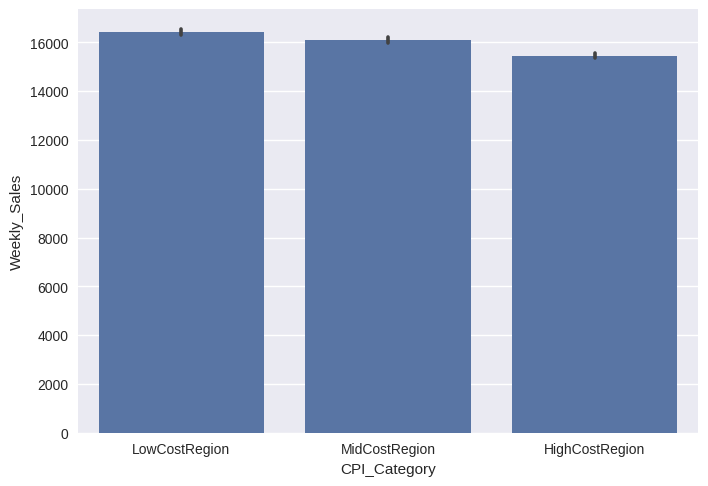

In [78]:
#sales vs cpi category
sns.barplot(x='CPI_Category', y='Weekly_Sales', data=merge_df)

<Axes: xlabel='Season', ylabel='Weekly_Sales'>

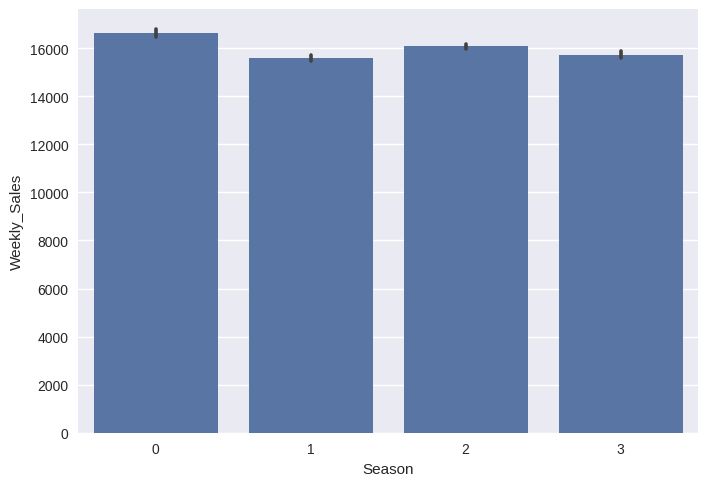

In [79]:
#season vs sakes
sns.barplot(x='Season', y='Weekly_Sales', data=merge_df)

Saving processed data

In [80]:
merge_df.to_csv('walmart_dataset_processed.csv', index=False)


In [81]:
merge_df.shape

(421570, 35)